In [1]:
# Written by David Schneidinger. Please modify as needed. Email me dschneidinger@g.ucla.edu if you have any questions
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../../src')
import osh5vis
import osh5io
import numpy as np
import os
import scipy
import matplotlib.pyplot as plt
import astropy
import moments
import analysis_utils

In [ ]:
# To do this right we need to transform to the shock rest frame
sim_dir = "/pscratch/sd/d/dschnei/perlmutter_1.3.1d"
sim = analysis_utils.MagShockZRun(sim_dir+'/magshockz_gpu.1d', norm_density=5e18 * astropy.units.cm**-3)

# Timesteps (OSIRIS units)
times = list(range(0, 400, 40))

# Species phase space
al_phase_space = [osh5io.read_h5(f"{sim_dir}/MS/PHA/p1x1/al/p1x1-al-{t:06d}.h5") for t in times]
e_phase_space = [osh5io.read_h5(f"{sim_dir}/MS/PHA/p1x1/e/p1x1-e-{t:06d}.h5") for t in times]
si_phase_space = [osh5io.read_h5(f"{sim_dir}/MS/PHA/p1x1/si/p1x1-si-{t:06d}.h5") for t in times]

# Electromagnetic fields
b1 = [osh5io.read_h5(f"{sim_dir}/MS/FLD/b1-savg/b1-savg-{t:06d}.h5") for t in times]
b2 = [osh5io.read_h5(f"{sim_dir}/MS/FLD/b2-savg/b2-savg-{t:06d}.h5") for t in times]
b3 = [osh5io.read_h5(f"{sim_dir}/MS/FLD/b3-savg/b3-savg-{t:06d}.h5") for t in times]
e1 = [osh5io.read_h5(f"{sim_dir}/MS/FLD/e1-savg/e1-savg-{t:06d}.h5") for t in times]
e2 = [osh5io.read_h5(f"{sim_dir}/MS/FLD/e2-savg/e2-savg-{t:06d}.h5") for t in times]
e3 = [osh5io.read_h5(f"{sim_dir}/MS/FLD/e3-savg/e3-savg-{t:06d}.h5") for t in times]

# Shock fit from your quicklook


In [3]:
b3[0].run_attrs['TIME UNITS']

osh5def.OSUnits at 0x7fbe4fe91400: ('m_e', 'c', '\\omega', 'e', 'n_0')=(0, 0, -1, 0, 0)

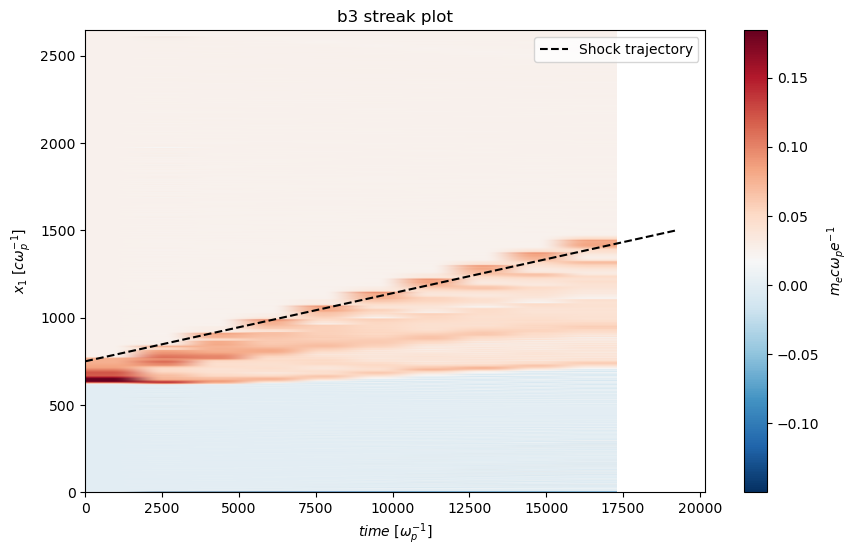

In [79]:
# 2D streak plot of b3
from analysis_utils import StreakBuilder

b3_streak = StreakBuilder(b3).build()

plt.figure(figsize=(10, 6))
osh5vis.osplot(b3_streak.T, cmap="RdBu_r")
plt.title("b3 streak plot")

v_shock = 0.039
x_shock_0 = 750.0
t_axis = np.linspace(b3[0].run_attrs["TIME"][0], b3[-1].run_attrs["TIME"][0], b3_streak.shape[0])
shockfront = v_shock * t_axis + x_shock_0
plt.plot(t_axis, shockfront, 'k--', label='Shock trajectory')
plt.legend()
plt.show()

B_unit = 7.166e+06 G (7.166e+02 T)
E_unit = 2.150e+00 GV / cm (2.150e+11 V / m)


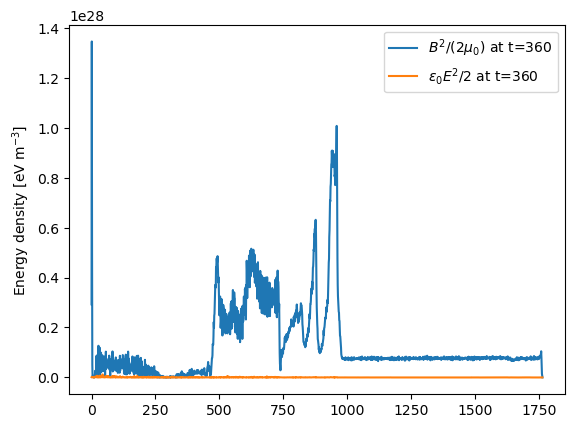

In [69]:
# Dimensionful field-energy densities from normalized OSIRIS fields
omega_pe_rad_s = (sim.omega_pe / astropy.units.rad).to(1 / astropy.units.s).value

# User-provided normalization checks:
# B [G]      = 5.681e-8  * B' * omega_p [rad/s]
# E [GV/cm]  = 1.704e-14 * E' * omega_p [rad/s]
B_unit = (5.681e-8 * omega_pe_rad_s) * astropy.units.Gauss
E_unit = (1.704e-14 * omega_pe_rad_s) * (astropy.units.GV / astropy.units.cm)

# Convert to SI for robust energy-density calculation
B_unit_SI = B_unit.to(astropy.units.T)
E_unit_SI = E_unit.to(astropy.units.V / astropy.units.m)

uE_unit = (0.5 * astropy.constants.eps0 * E_unit_SI**2).to(astropy.units.erg / astropy.units.cm**3)
uB_unit = (0.5 * B_unit_SI**2 / astropy.constants.mu0).to(astropy.units.erg / astropy.units.cm**3)

ene_B_field = []
ene_E_field = []
for i in range(len(times)):
    B2 = np.square(np.asarray(b1[i])) + np.square(np.asarray(b2[i])) + np.square(np.asarray(b3[i]))
    E2 = np.square(np.asarray(e1[i])) + np.square(np.asarray(e2[i])) + np.square(np.asarray(e3[i]))
    ene_B_field.append((B2 * uB_unit).to(astropy.units.eV / astropy.units.m**3))
    ene_E_field.append((E2 * uE_unit).to(astropy.units.eV / astropy.units.m**3))

i = -1
plt.plot(ene_B_field[i].value, label=f"$B^2/(2\\mu_0)$ at t={times[i]}")
plt.plot(ene_E_field[i].value, label=f"$\\epsilon_0 E^2/2$ at t={times[i]}")
plt.ylabel(r"Energy density [eV m$^{-3}$]")
plt.legend()

print(f"B_unit = {B_unit:.3e} ({B_unit_SI:.3e})")
print(f"E_unit = {E_unit:.3e} ({E_unit_SI:.3e})")

In [68]:
# Look at t = 0 energy partition to start
T_al = np.array([(moments.moment(al_phase_space[i], axis = "p1", order = 2)
        * astropy.constants.m_e * astropy.constants.c**2 * sim.rqm).to(astropy.units.eV) for i in range(len(al_phase_space))])
T_e = np.array([(moments.moment(e_phase_space[i], axis = "p1", order = 2)
       * astropy.constants.m_e * astropy.constants.c**2).to(astropy.units.eV) for i in range(len(e_phase_space))])
T_si = np.array([(moments.moment(si_phase_space[i], axis = "p1", order = 2)
       * astropy.constants.m_e * astropy.constants.c**2 * sim.rqm).to(astropy.units.eV) for i in range(len(si_phase_space))])


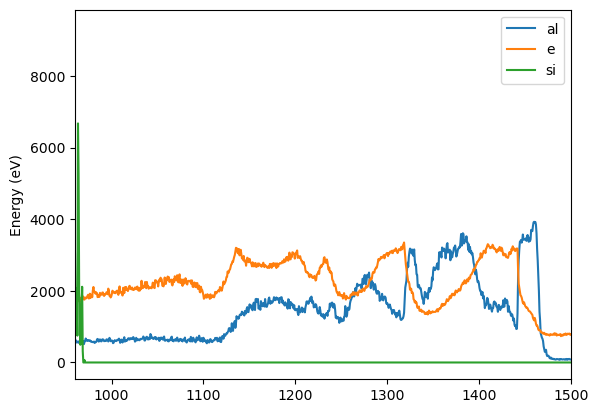

In [ ]:
plt.plot(x_axis, T_al[-1], label="al")
plt.plot(x_axis, T_e[-1], label="e")
plt.plot(x_axis, T_si[-1], label="si")
plt.xlim(960,1500) # downstream starts at 960
plt.ylabel("Energy (eV)")
plt.legend()
plt.show()


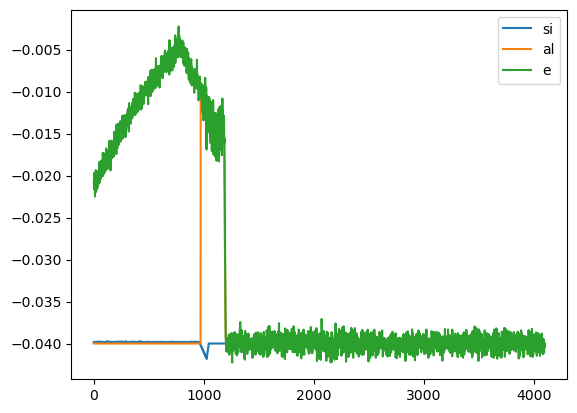

In [40]:
v_si_x = moments.moment(si_phase_space[0], axis = "p1", order = 1)
v_al_x = moments.moment(al_phase_space[0], axis = "p1", order = 1)
v_e_x = moments.moment(e_phase_space[0], axis = "p1", order = 1)
# transform to shock RF
v_si_x -=  v_shock
v_al_x -=  v_shock
v_e_x -=  v_shock

plt.plot(v_si_x, label="si")
plt.plot(v_al_x, label="al")
plt.plot(v_e_x, label="e")

plt.legend()

In [ ]:
ram_pressure_al = np.array([])
t = -1
ram_pressure_al = (np.multiply(np.square(moments.moment(al_phase_space[t], axis = "p1", order = 1) - v_shock),
                                        moments.moment(al_phase_space[t], axis = "p1", order = 0))
                        * sim.rqm * astropy.constants.m_e * astropy.constants.c**2).to(astropy.units.eV)

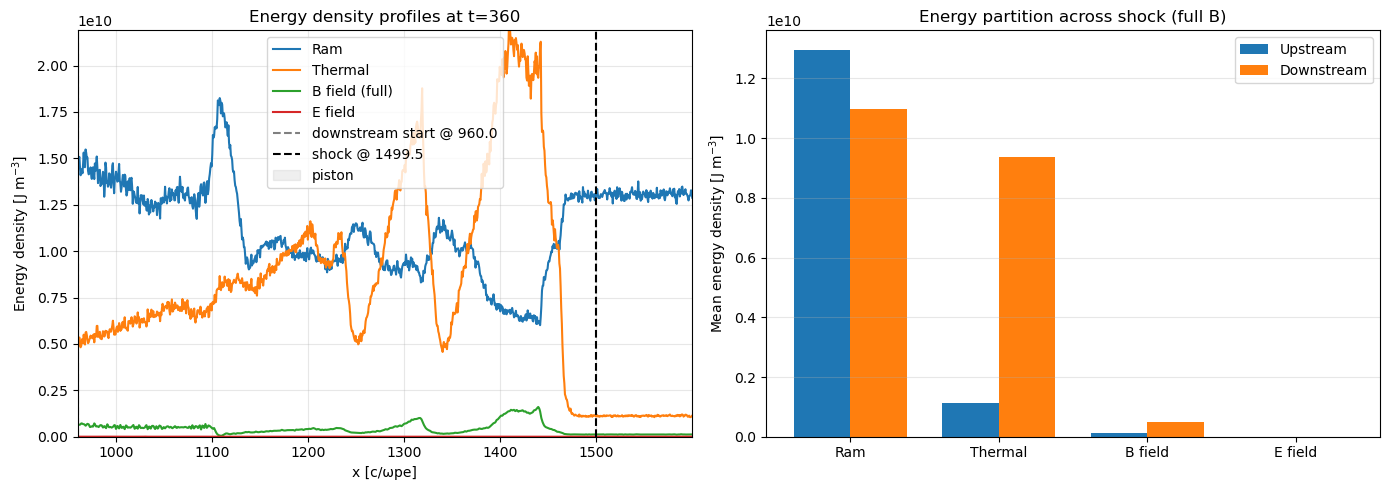

t = 360, x_downstream_start = 960.00, x_shock = 1499.46 [c/ωpe]
B_unit = 7.166e+06 G, E_unit = 2.150e+00 GV / cm
field_mode = full
upstream <|B|>_norm ≈ 2.443e-02, upstream <|B|> ≈ 1.751e+01 T
u_B from upstream <|B|> ≈ 1.220e+08 J / m3
Upstream  [J/m^3]: {'Ram': 12962435020.661152, 'Thermal': 1124524559.0353255, 'B field': 122032719.37811176, 'E field': 159315.52814798095}
Downstream[J/m^3]: {'Ram': 10973253196.42415, 'Thermal': 9356808909.194088, 'B field': 478421037.8082189, 'E field': 889782.837457215}


In [ ]:
# Full, dimensionful energy partition for one timestep in the shock frame
eps0 = astropy.constants.eps0
mu0 = astropy.constants.mu0
m_e = astropy.constants.m_e
c = astropy.constants.c

# Choose timestep index in `times`
t_idx = -1
t_val = times[t_idx]

# Phase-space grid (used for particle energies and region masks)
x_axis = np.linspace(
    al_phase_space[t_idx].axes[1].min,
    al_phase_space[t_idx].axes[1].max,
    al_phase_space[t_idx].axes[1].size,
)

# Region boundaries (tunable)
x_shock = x_shock_0 + v_shock * al_phase_space[t_idx].run_attrs['TIME'][0]
x_downstream_start = 960.0

# Field mode:
#   "full"  -> use total field energy density
#   "delta" -> subtract upstream mean B before computing magnetic energy
field_mode = "full"

# Masks: piston | downstream | upstream
piston = x_axis < x_downstream_start
downstream = (x_axis >= x_downstream_start) & (x_axis <= x_shock)
upstream = x_axis > x_shock

if downstream.sum() == 0 or upstream.sum() == 0:
    raise ValueError(
        "Empty downstream or upstream mask. Adjust x_downstream_start and/or shock location."
    )

# Plasma normalization
n0_si = sim.norm_density.to(astropy.units.m**-3)

# Field normalization using user-provided relations
omega_pe_rad_s = (sim.omega_pe / astropy.units.rad).to(1 / astropy.units.s).value
B_unit = (5.681e-8 * omega_pe_rad_s) * astropy.units.Gauss
E_unit = (1.704e-14 * omega_pe_rad_s) * (astropy.units.GV / astropy.units.cm)
B_unit_SI = B_unit.to(astropy.units.T)
E_unit_SI = E_unit.to(astropy.units.V / astropy.units.m)

# Helper: species ram and thermal energy density from moments
def species_energy_profiles(phase_space, mass, species_name):
    n_norm_raw = moments.moment(phase_space, axis="p1", order=0)
    # Electron diagnostics are often charge-weighted; enforce number density >= 0.
    n_norm = np.abs(n_norm_raw)

    u_norm = moments.moment(phase_space, axis="p1", order=1) - v_shock  # shock frame
    vth2_norm = moments.moment(phase_space, axis="p1", order=2)

    # Variance should be >= 0; clip tiny numerical negatives.
    vth2_norm = np.maximum(vth2_norm, 0.0)

    n_si = n_norm * n0_si
    u_si = u_norm * c
    kT_si = vth2_norm * mass * c**2

    u_ram = (0.5 * n_si * mass * u_si**2).to(astropy.units.J / astropy.units.m**3)
    u_th = (n_si * kT_si).to(astropy.units.J / astropy.units.m**3)

    return u_ram.value, u_th.value

# Species masses: always positive
m_ion = np.abs(sim.rqm) * m_e

u_ram_e, u_th_e = species_energy_profiles(e_phase_space[t_idx], m_e, "e")
u_ram_al, u_th_al = species_energy_profiles(al_phase_space[t_idx], m_ion, "al")
u_ram_si, u_th_si = species_energy_profiles(si_phase_space[t_idx], m_ion, "si")

u_ram_total = u_ram_e + u_ram_al + u_ram_si
u_th_total = u_th_e + u_th_al + u_th_si

# Field energy density on field grid
x_field = np.linspace(
    b1[t_idx].axes[0].min,
    b1[t_idx].axes[0].max,
    b1[t_idx].axes[0].size,
)
b1_arr = np.asarray(b1[t_idx])
b2_arr = np.asarray(b2[t_idx])
b3_arr = np.asarray(b3[t_idx])
e1_arr = np.asarray(e1[t_idx])
e2_arr = np.asarray(e2[t_idx])
e3_arr = np.asarray(e3[t_idx])

E2 = np.square(e1_arr) + np.square(e2_arr) + np.square(e3_arr)
B2_full = np.square(b1_arr) + np.square(b2_arr) + np.square(b3_arr)

# Background-subtracted B (optional diagnostic)
upstream_field = x_field > x_shock
if np.any(upstream_field):
    b1_bg = np.nanmean(b1_arr[upstream_field])
    b2_bg = np.nanmean(b2_arr[upstream_field])
    b3_bg = np.nanmean(b3_arr[upstream_field])
else:
    b1_bg = b2_bg = b3_bg = 0.0

B2_delta = np.square(b1_arr - b1_bg) + np.square(b2_arr - b2_bg) + np.square(b3_arr - b3_bg)

E_si2 = E2 * (E_unit_SI**2)
B_si2_full = B2_full * (B_unit_SI**2)
B_si2_delta = B2_delta * (B_unit_SI**2)

u_E_fieldgrid = (0.5 * eps0 * E_si2).to(astropy.units.J / astropy.units.m**3).value
u_B_full_fieldgrid = (0.5 * B_si2_full / mu0).to(astropy.units.J / astropy.units.m**3).value
u_B_delta_fieldgrid = (0.5 * B_si2_delta / mu0).to(astropy.units.J / astropy.units.m**3).value

u_B_fieldgrid = u_B_full_fieldgrid if field_mode == "full" else u_B_delta_fieldgrid
u_field_fieldgrid = u_B_fieldgrid + u_E_fieldgrid

# Interpolate field energies onto phase-space grid for consistent side averages
u_E = np.interp(x_axis, x_field, u_E_fieldgrid)
u_B = np.interp(x_axis, x_field, u_B_fieldgrid)
u_field = np.interp(x_axis, x_field, u_field_fieldgrid)

# Side-averaged partition
def side_mean(arr, mask):
    return float(np.nanmean(arr[mask]))

partition_up = {
    "Ram": side_mean(u_ram_total, upstream),
    "Thermal": side_mean(u_th_total, upstream),
    "B field": side_mean(u_B, upstream),
    "E field": side_mean(u_E, upstream),
}
partition_down = {
    "Ram": side_mean(u_ram_total, downstream),
    "Thermal": side_mean(u_th_total, downstream),
    "B field": side_mean(u_B, downstream),
    "E field": side_mean(u_E, downstream),
}

# Plot profiles + side-by-side partition bars
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(x_axis, u_ram_total, label="Ram")
ax[0].plot(x_axis, u_th_total, label="Thermal")
ax[0].plot(x_axis, u_B, label=f"B field ({field_mode})")
ax[0].plot(x_axis, u_E, label="E field")
ax[0].axvline(x_downstream_start, color="gray", linestyle="--", label=f"downstream start @ {x_downstream_start:.1f}")
ax[0].axvline(x_shock, color="k", linestyle="--", label=f"shock @ {x_shock:.1f}")
ax[0].axvspan(x_axis.min(), x_downstream_start, color="gray", alpha=0.12, label="piston")
ax[0].set_xlabel("x [c/ωpe]")
ax[0].set_ylabel("Energy density [J m$^{-3}$]")
ax[0].set_title(f"Energy density profiles at t={t_val}")
ax[0].legend()
ax[0].grid(alpha=0.3)
ax[0].set_xlim(x_downstream_start, x_shock + 100)
ax[0].set_ylim(0, np.nanmax(u_ram_total[downstream]) * 1.2)

labels = ["Ram", "Thermal", "B field", "E field"]
x = np.arange(len(labels))
w = 0.38
ax[1].bar(x - w / 2, [partition_up[k] for k in labels], w, label="Upstream")
ax[1].bar(x + w / 2, [partition_down[k] for k in labels], w, label="Downstream")
ax[1].set_xticks(x)
ax[1].set_xticklabels(labels)
ax[1].set_ylabel("Mean energy density [J m$^{-3}$]")
ax[1].set_title(f"Energy partition across shock ({field_mode} B)")
ax[1].legend()
ax[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Normalization sanity checks
Bmag_upstream_norm = np.sqrt(np.nanmean(B2_full[upstream_field])) if np.any(upstream_field) else np.nan
Bmag_upstream_SI = Bmag_upstream_norm * B_unit_SI
u_B_upstream_from_Bmag = (0.5 * Bmag_upstream_SI**2 / mu0).to(astropy.units.J / astropy.units.m**3)

print(f"t = {t_val}, x_downstream_start = {x_downstream_start:.2f}, x_shock = {x_shock:.2f} [c/ωpe]")
print(f"B_unit = {B_unit:.3e}, E_unit = {E_unit:.3e}")
print(f"field_mode = {field_mode}")
print(f"upstream <|B|>_norm ≈ {Bmag_upstream_norm:.3e}, upstream <|B|> ≈ {Bmag_upstream_SI:.3e}")
print(f"u_B from upstream <|B|> ≈ {u_B_upstream_from_Bmag:.3e}")
print("Upstream  [J/m^3]:", partition_up)
print("Downstream[J/m^3]:", partition_down)

In [76]:
print(f"sim.rqm = {sim.rqm}")

# Quick consistency checks against final-cell arrays
up = upstream
print(f"<n_e_norm> upstream = {np.nanmean(np.abs(moments.moment(e_phase_space[t_idx], axis='p1', order=0))[up]):.3e}")
print(f"<n_al_norm> upstream = {np.nanmean(np.abs(moments.moment(al_phase_space[t_idx], axis='p1', order=0))[up]):.3e}")
print(f"<n_si_norm> upstream = {np.nanmean(np.abs(moments.moment(si_phase_space[t_idx], axis='p1', order=0))[up]):.3e}")

u_ram_up = np.nanmean(u_ram_total[up])
u_th_up = np.nanmean(u_th_total[up])
u_B_up = np.nanmean(u_B[up])
u_E_up = np.nanmean(u_E[up])
print(f"Upstream ratios: uB/uRam={u_B_up/u_ram_up:.3e}, uE/uRam={u_E_up/u_ram_up:.3e}, uTh/uRam={u_th_up/u_ram_up:.3e}")

sim.rqm = 38.0
<n_e_norm> upstream = 1.067e+00
<n_al_norm> upstream = 1.067e+00
<n_si_norm> upstream = 0.000e+00
Upstream ratios: uB/uRam=8.953e-03, uE/uRam=1.168e-05, uTh/uRam=8.249e-02
